In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

# 设置绘图显示中文和负号
plt.rcParams['font.sans-serif'] = ['Heiti TC']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号


,面积,房龄,距市中心距离,房价
0,152,28,3.41,108.23
1,142,25,10.92,101.04
2,64,25,15.63,24.53
3,156,18,5.10,141.95
4,121,23,12.83,90.53



--- 数据信息 ---
<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   面积      200 non-null    int64  
 1   房龄      200 non-null    int64  
 2   距市中心距离  200 non-null    float64
 3   房价      200 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 7.8 KB

 数据描述信息：
               面积          房龄      距市中心距离          房价
count  200.000000  200.000000  200.000000  200.000000
mean   126.750000   15.580000   10.464050  105.651350
std     43.518811    8.867738    5.780356   39.644476
min     50.000000    1.000000    1.210000   -0.390000
25%     90.000000    8.000000    5.212500   75.042500
50%    130.500000   16.500000   10.865000  109.020000
75%    165.250000   23.000000   15.317500  134.215000
max    199.000000   29.000000   19.870000  190.520000

--- 缺失值检查 ---
面积        0
房龄        0
距市中心距离    0
房价        0
dtype: int64

--- 数据分布可视化 ---


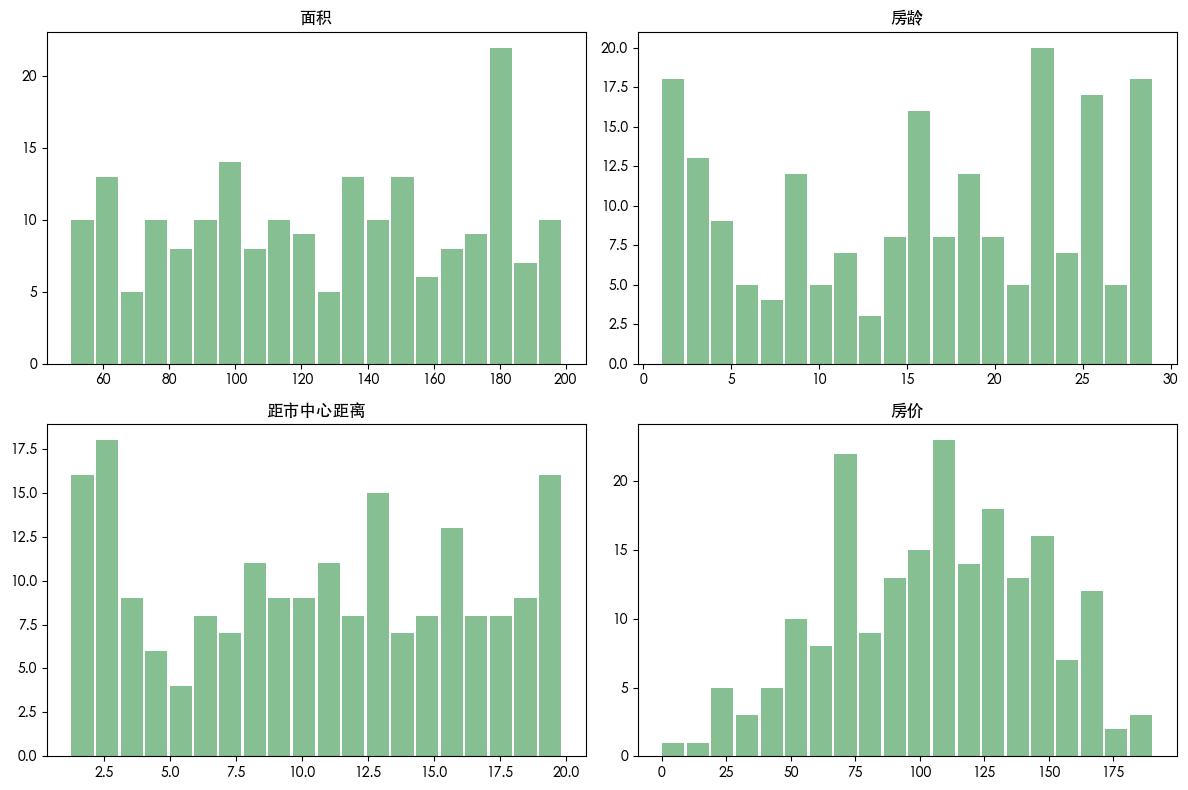


--- 异常值检查 (箱线图) ---


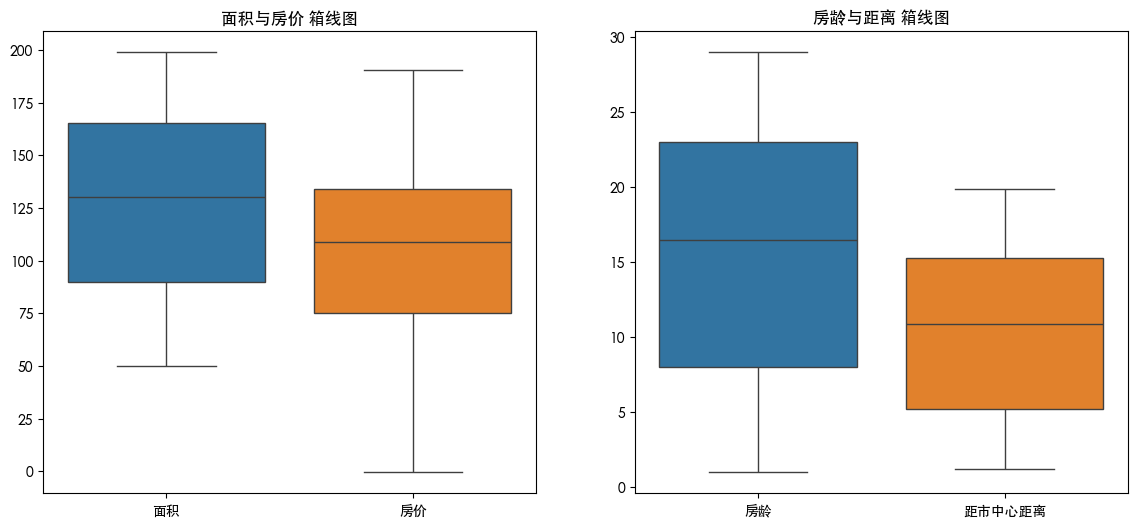


--- 特征相关性热力图 ---


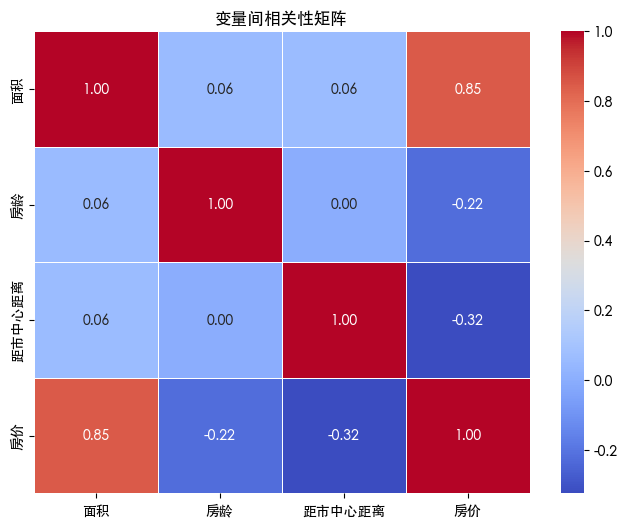


数据拆分完成：训练集 160 条，测试集 40 条


In [11]:
# 读取数据
file_path = '../datasets/house_data.csv'

# 预览前5行
display(df.head())

# 查看数据结构信息
print("\n--- 数据信息 ---")
df.info()

# 基本统计描述
print("\n 数据描述信息：")
print(df.describe())

# 缺失值检查
print("\n--- 缺失值检查 ---")
missing_values = df.isnull().sum()
print(missing_values)

# 如果有缺失值，进行填充
if missing_values.any():
    print("\n发现缺失值，正在用均值填充...")
    df = df.fillna(df.mean())

# 可视化分布 (直方图)
print("\n--- 数据分布可视化 ---")
# 绘制所有数值型列的直方图
df.hist(bins=20, figsize=(12, 8), grid=False, color='#86bf91', zorder=2, rwidth=0.9)
plt.tight_layout()
plt.show()

# 异常值检查 (箱线图)
print("\n--- 异常值检查 (箱线图) ---")
plt.figure(figsize=(14, 6))

# 为了显示效果，我们将“房价”、“面积”这种大数值的字段和“房龄”这种小数值的分开画，或者直接画在一起观察
plt.subplot(1, 2, 1)
sns.boxplot(data=df[['面积', '房价']])
plt.title('面积与房价 箱线图')

plt.subplot(1, 2, 2)
sns.boxplot(data=df[['房龄', '距市中心距离']])
plt.title('房龄与距离 箱线图')
plt.show()

# 相关性热力图
print("\n--- 特征相关性热力图 ---")
plt.figure(figsize=(8, 6))
# 计算相关系数矩阵
corr_matrix = df.corr()
# 绘制热力图：annot=True显示数值，cmap='coolwarm'设置红蓝配色
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('变量间相关性矩阵')
plt.show()

# --- 数据预处理结束，开始拆分 ---

# 定义特征和目标
feature_cols = ['面积', '房龄', '距市中心距离']
target_col = '房价'
X = df[feature_cols]
y = df[target_col]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n数据拆分完成：训练集 {X_train.shape[0]} 条，测试集 {X_test.shape[0]} 条")

In [13]:
print("正在训练多元线性回归模型...")
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

print("线性回归预测完成。")

# 查看回归系数
coef_df = pd.DataFrame(lin_reg.coef_, index=feature_cols, columns=['系数 (Coefficient)'])
print("\n模型系数解读：")
display(coef_df)
print(f"截距 (Intercept): {lin_reg.intercept_:.2f}")


正在训练多元线性回归模型...
线性回归预测完成。

模型系数解读：


,系数 (Coefficient)
面积,0.802178
房龄,-1.220667
距市中心距离,-2.593616


截距 (Intercept): 50.46


In [15]:
print("正在训练决策树回归模型...")
tree_reg = DecisionTreeRegressor(random_state=42, max_depth=5)
tree_reg.fit(X_train, y_train)
y_pred_tree = tree_reg.predict(X_test)

print("决策树预测完成。")

正在训练决策树回归模型...
决策树预测完成。


In [17]:
# 计算指标
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

# 打印对比表格
print("\n" + "="*45)
print("模型评估结果对比")
print("="*45)
print(f"{'模型名称':<15} | {'MSE (均方误差)':<15} | {'R2 Score':<15}")
print("-" * 60)
print(f"{'多元线性回归':<15} | {mse_lin:<15.4f} | {r2_lin:<15.4f}")
print(f"{'决策树回归':<15} | {mse_tree:<15.4f} | {r2_tree:<15.4f}")
print("-" * 60)



模型评估结果对比
模型名称            | MSE (均方误差)      | R2 Score       
------------------------------------------------------------
多元线性回归          | 91.5332         | 0.9449         
决策树回归           | 299.7374        | 0.8197         
------------------------------------------------------------


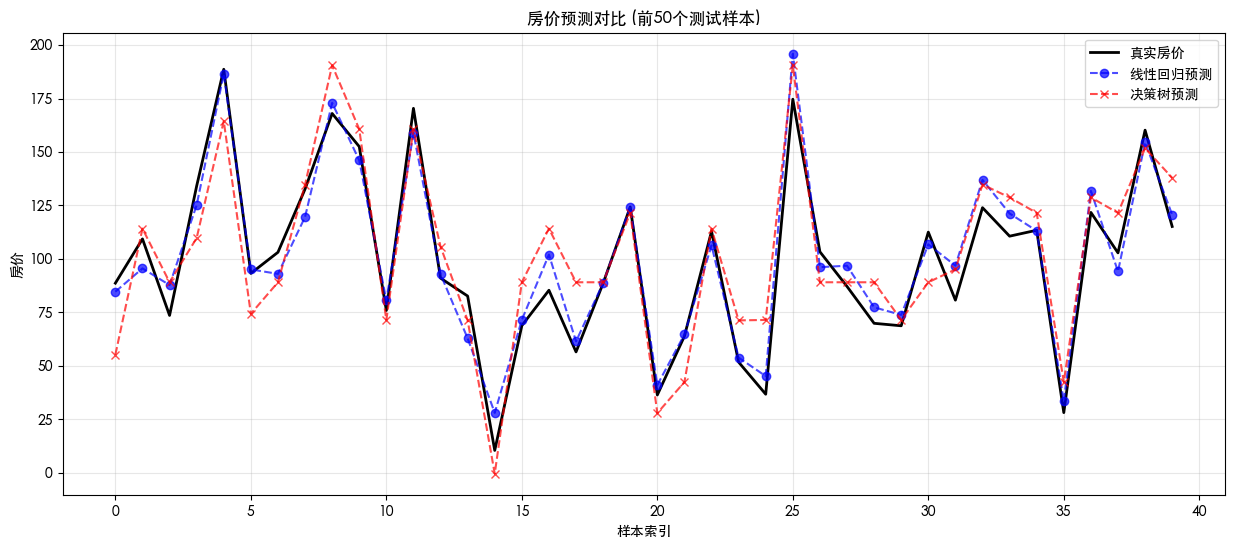

In [19]:
plt.figure(figsize=(15, 6))
limit = 50
x_axis = range(len(y_test[:limit]))

plt.plot(x_axis, y_test[:limit], color='black', label='真实房价', linewidth=2)
plt.plot(x_axis, y_pred_lin[:limit], color='blue', linestyle='--', marker='o', label='线性回归预测', alpha=0.7)
plt.plot(x_axis, y_pred_tree[:limit], color='red', linestyle='--', marker='x', label='决策树预测', alpha=0.7)

plt.title('房价预测对比 (前50个测试样本)')
plt.xlabel('样本索引')
plt.ylabel('房价')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


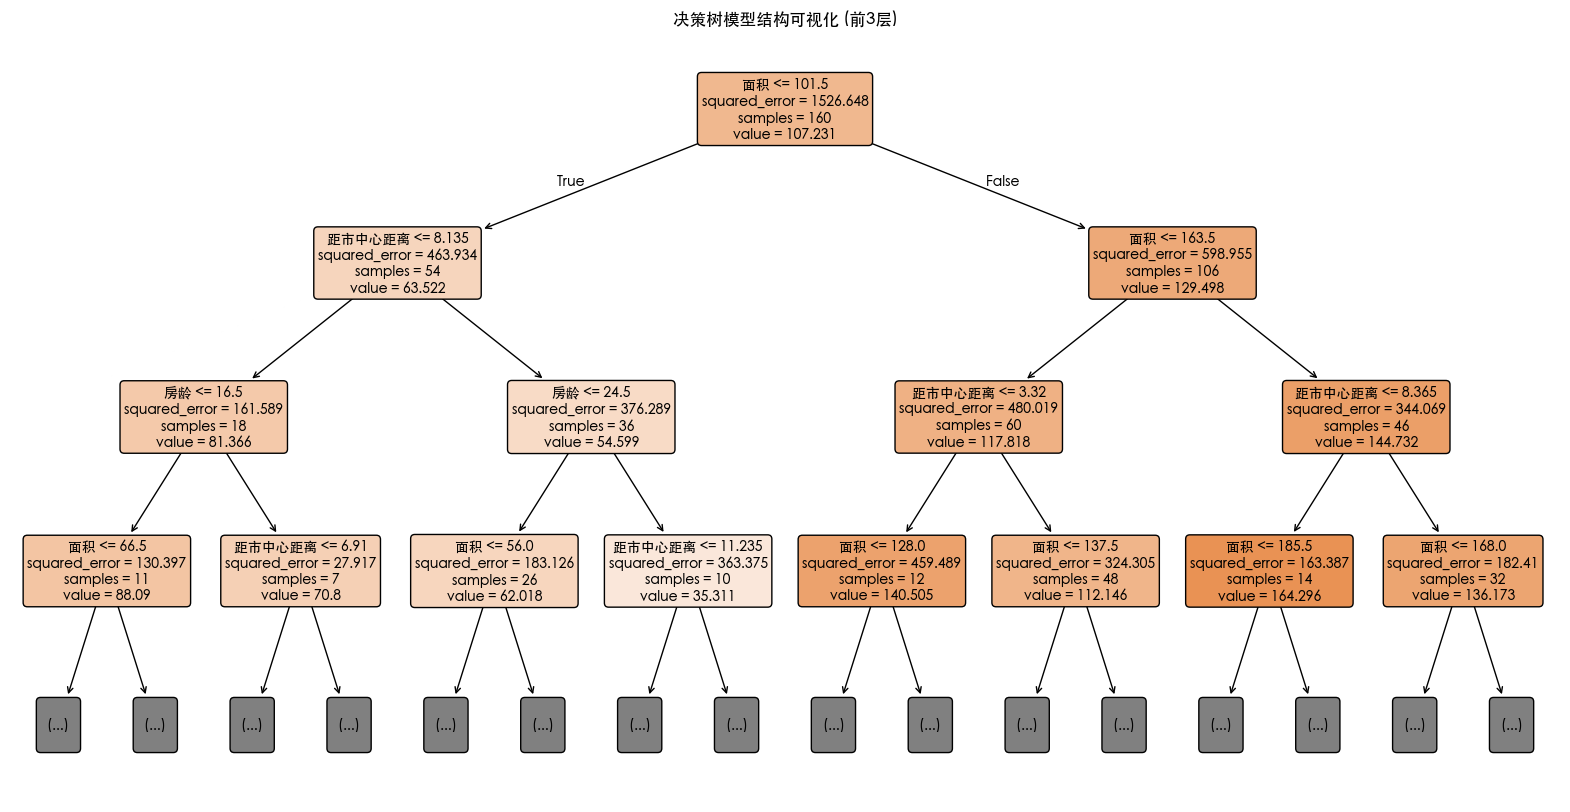

In [26]:
plt.figure(figsize=(20, 10), dpi=100) # 设置较大的画布以看清细节

# 绘制决策树
plot_tree(tree_reg, 
          feature_names=feature_cols, 
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=3) # 为了显示清晰，这里只显示前3层，你可以改为 None 显示全树

plt.title("决策树模型结构可视化 (前3层)")
plt.show()


# 结论：多元线性回归的效果更好